# Factor-level enrichment v3 (Factor_ER_v3)

Rebuild of `Factor_ER_v2.ipynb`, changed as follows:
- Tests the same 14 resource x direction categories used in `p_combined_two_level`
  (`Global_ER_replotting.ipynb`) - CollecTRI, SCENIC activator, SCENIC repressor,
  RBP, Liana L-R, MEROPS (each forward/reverse), and PPI strict/lenient - instead
  of the old 5 direction-agnostic categories (`has_TF`/`has_RBP`/`has_LR`/`has_PPI`/`has_cascade`).
- Full graph only (`Within-only` vs `Across-only`, Mixed excluded) - the
  `full` vs `GWAS_colocalized` split from v2 is dropped.
- Both raw Fisher's exact test AND size-corrected logistic regression
  (`has_X ~ edge_type_composition + n_edges`) are kept, shown as two facets
  side by side.
- Same y-axis row labels/order and resource colors as `p_combined_two_level`,
  plus a matching composition stacked barplot (% Within vs Across among
  annotated/positive factors per category).
- No exosome row (not applicable to this resource-only analysis) and no
  gene-pair-level facet (this notebook is factor-level only).


# Load libraries

In [1]:
suppressMessages(library("data.table"))
suppressMessages(library("ggplot2"))
suppressMessages(library("patchwork"))
suppressMessages(library("scales"))


# PATH

In [2]:
master_dir <- "/nfs/team151/mt19/overhaul_classification_factors_with_programs/"
outdir <- paste0(master_dir, "Factor_ER/")
dir.create(outdir, recursive = TRUE, showWarnings = FALSE)
cat("Master directory:", master_dir, "\n")
cat("Created:", outdir, "\n")


Master directory: /nfs/team151/mt19/overhaul_classification_factors_with_programs/ 
Created: /nfs/team151/mt19/overhaul_classification_factors_with_programs/Factor_ER/ 


# Load data

In [3]:
whole_eqtl_annotated <- readRDS(file = paste0(master_dir, "whole_eqtl_annotated.rds"))
cat("whole_eqtl_annotated:", nrow(whole_eqtl_annotated), "rows\n")


whole_eqtl_annotated: 305496 rows


# Step 1: Factor-level topology (full graph only)

Factor key: `(Source_module, Source_gene, program)`. Mixed-composition
factors are excluded from testing, consistent with the rest of this
project's Within-only vs Across-only convention (and Methods.md's note that
no factors have Mixed composition under program stratification).

In [4]:
factor_topology_final <- whole_eqtl_annotated[
  , .(n_edges = .N, n_within = sum(edge.type == "Within"), n_across = sum(edge.type == "Across")),
  by = .(Source_module, Source_gene, program)
]
factor_topology_final[, edge_type_composition := fcase(
  n_within > 0 & n_across == 0, "Within-only",
  n_across > 0 & n_within == 0, "Across-only",
  n_within > 0 & n_across > 0,  "Mixed"
)]

cat("Factor-level composition (all factors):\n")
print(factor_topology_final[, .N, by = edge_type_composition])

factors_for_testing <- factor_topology_final[edge_type_composition %in% c("Within-only", "Across-only")]
cat("\nFactors used for testing (Mixed excluded):", nrow(factors_for_testing), "/", nrow(factor_topology_final), "\n")


Factor-level composition (all factors):
   edge_type_composition     N
                  <char> <int>
1:           Within-only  2018
2:           Across-only  1149

Factors used for testing (Mixed excluded): 3167 / 3167 


# Step 2: Annotate factors with the 14 resource x direction categories

Forward = cis-eQTL gene (`Source_gene`) plays the "active"/upstream role
(regulator, Ligand, Peptidase). Reverse = cis-eQTL gene plays the
"passive"/downstream role. PPI is undirected by construction, so it gets
strict/lenient stringency bands instead of a direction split. Regexes are
identical to those used throughout this project's cis-eQTL-level notebook.

In [5]:
tf_forward_regex <- "Source_TF->Target|Source_TF_activator->Target|Source_TF_repressor->Target"
tf_reverse_regex <- "Target_TF->Source|Target_TF_activator->Source|Target_TF_repressor->Source"
rbp_forward_regex <- "Source_RBP->Target"
rbp_reverse_regex <- "Target_RBP->Source"
liana_forward_regex  <- "Source_Ligand->Target_Receptor"
liana_reverse_regex  <- "Target_Ligand->Source_Receptor"
merops_forward_regex <- "Source_Peptidase->Target_Substrate"
merops_reverse_regex <- "Target_Peptidase->Source_Substrate"
ppi_strict_pattern  <- "PPI (STRING_experimental >=0.4)"
ppi_lenient_pattern <- "PPI (STRING_experimental >=0.1 <0.4)"

## TF split into CollecTRI vs SCENIC activator vs SCENIC repressor, each
## with its own forward/reverse pair - matches p_combined_two_level's scheme,
## unlike v2's single direction-agnostic has_TF (CollecTRI-only, no direction).
collectri_forward_regex  <- "Source_TF->Target"
collectri_reverse_regex  <- "Target_TF->Source"
scenic_act_forward_regex <- "Source_TF_activator->Target"
scenic_act_reverse_regex <- "Target_TF_activator->Source"
scenic_rep_forward_regex <- "Source_TF_repressor->Target"
scenic_rep_reverse_regex <- "Target_TF_repressor->Source"

factor_annotation_full <- whole_eqtl_annotated[
  factors_for_testing[, .(Source_module, Source_gene, program)],
  on = .(Source_module, Source_gene, program), nomatch = 0
][, .(
    has_CollecTRI_source        = any(!is.na(edge_role) & grepl(collectri_forward_regex, edge_role, fixed = TRUE)),
    has_CollecTRI_target        = any(!is.na(edge_role) & grepl(collectri_reverse_regex, edge_role, fixed = TRUE)),
    has_SCENIC_activator_source = any(!is.na(edge_role) & grepl(scenic_act_forward_regex, edge_role, fixed = TRUE)),
    has_SCENIC_activator_target = any(!is.na(edge_role) & grepl(scenic_act_reverse_regex, edge_role, fixed = TRUE)),
    has_SCENIC_repressor_source = any(!is.na(edge_role) & grepl(scenic_rep_forward_regex, edge_role, fixed = TRUE)),
    has_SCENIC_repressor_target = any(!is.na(edge_role) & grepl(scenic_rep_reverse_regex, edge_role, fixed = TRUE)),
    has_RBP_source     = any(!is.na(edge_role) & grepl(rbp_forward_regex, edge_role, fixed = TRUE)),
    has_RBP_target     = any(!is.na(edge_role) & grepl(rbp_reverse_regex, edge_role, fixed = TRUE)),
    has_LR_source       = any(!is.na(edge_role) & grepl(liana_forward_regex, edge_role, fixed = TRUE)),
    has_LR_target       = any(!is.na(edge_role) & grepl(liana_reverse_regex, edge_role, fixed = TRUE)),
    has_MEROPS_source   = any(!is.na(edge_role) & grepl(merops_forward_regex, edge_role, fixed = TRUE)),
    has_MEROPS_target   = any(!is.na(edge_role) & grepl(merops_reverse_regex, edge_role, fixed = TRUE)),
    has_PPI_strict      = any(!is.na(edge_role) & grepl(ppi_strict_pattern, edge_role, fixed = TRUE)),
    has_PPI_lenient     = any(!is.na(edge_role) & grepl(ppi_lenient_pattern, edge_role, fixed = TRUE))
  ), by = .(Source_module, Source_gene, program)]

factors_for_testing <- merge(factors_for_testing, factor_annotation_full,
                              by = c("Source_module", "Source_gene", "program"), all.x = TRUE)
stopifnot(nrow(factors_for_testing) == nrow(factor_annotation_full))

categories <- c("has_CollecTRI_source", "has_CollecTRI_target",
                 "has_SCENIC_activator_source", "has_SCENIC_activator_target",
                 "has_SCENIC_repressor_source", "has_SCENIC_repressor_target",
                 "has_RBP_source", "has_RBP_target",
                 "has_LR_source", "has_LR_target",
                 "has_MEROPS_source", "has_MEROPS_target",
                 "has_PPI_strict", "has_PPI_lenient")

cat("Categories tested:\n")
print(categories)


Categories tested:
 [1] "has_CollecTRI_source"        "has_CollecTRI_target"       
 [3] "has_SCENIC_activator_source" "has_SCENIC_activator_target"
 [5] "has_SCENIC_repressor_source" "has_SCENIC_repressor_target"
 [7] "has_RBP_source"              "has_RBP_target"             
 [9] "has_LR_source"               "has_LR_target"              
[11] "has_MEROPS_source"           "has_MEROPS_target"          
[13] "has_PPI_strict"              "has_PPI_lenient"            


# Step 3: Fisher's exact test

Explicit factor level order (`Within-only` before `Across-only`) fixes the
odds-ratio direction as odds(Across)/odds(Within), consistent with every
other Fisher test in this project (rather than depending on `table()`'s
default alphabetical row order).

In [6]:
run_fisher_comparison <- function(dt, category_col) {
  comp_factor <- factor(dt$edge_type_composition, levels = c("Within-only", "Across-only"))
  tab <- table(comp_factor, dt[[category_col]])
  if (!"TRUE"  %in% colnames(tab)) tab <- cbind(tab, "TRUE" = 0)
  if (!"FALSE" %in% colnames(tab)) tab <- cbind(tab, "FALSE" = 0)
  tab <- tab[, c("FALSE", "TRUE")]
  if (!all(c("Within-only", "Across-only") %in% rownames(tab))) {
    return(data.table(category = category_col, status = "insufficient_data"))
  }
  ft <- fisher.test(tab)
  data.table(
    category = category_col,
    n_within_pos = tab["Within-only", "TRUE"], n_within_total = sum(tab["Within-only", ]),
    n_across_pos = tab["Across-only", "TRUE"], n_across_total = sum(tab["Across-only", ]),
    odds_ratio = unname(ft$estimate), ci_low = ft$conf.int[1], ci_high = ft$conf.int[2],
    p_value = ft$p.value
  )
}

fisher_results <- rbindlist(lapply(categories, function(cat_col) run_fisher_comparison(factors_for_testing, cat_col)), fill = TRUE)
if (!"status" %in% names(fisher_results)) fisher_results[, status := NA_character_]
fisher_results[is.na(status) | status != "insufficient_data", p_adj_BH := p.adjust(p_value, method = "BH")]

print(fisher_results)


                       category n_within_pos n_within_total n_across_pos
                         <char>        <num>          <num>        <num>
 1:        has_CollecTRI_source           86           2018           15
 2:        has_CollecTRI_target           20           2018            6
 3: has_SCENIC_activator_source          111           2018           19
 4: has_SCENIC_activator_target          187           2018           77
 5: has_SCENIC_repressor_source           75           2018           11
 6: has_SCENIC_repressor_target           46           2018           50
 7:              has_RBP_source            3           2018            2
 8:              has_RBP_target           45           2018           24
 9:               has_LR_source            6           2018            1
10:               has_LR_target            3           2018            5
11:           has_MEROPS_source            0           2018            0
12:           has_MEROPS_target            2       

# Step 4: Size-corrected logistic regression

`has_X ~ edge_type_composition + n_edges` (binomial), including factor size
(total edge count) as a covariate, since Across-only factors are on average
much larger by edge count than Within-only factors (per Methods.md, ~5x in
the earlier build) - this is the confound the size correction is meant to
address, complementary to the raw Fisher's exact test above.

In [7]:
run_logistic_comparison <- function(dt, category_col) {
  dt_glm <- copy(dt)
  dt_glm[, edge_type_composition := factor(edge_type_composition, levels = c("Within-only", "Across-only"))]
  form <- as.formula(paste0(category_col, " ~ edge_type_composition + n_edges"))
  m <- tryCatch(glm(form, data = dt_glm, family = binomial), error = function(e) NULL)
  if (is.null(m)) return(data.table(category = category_col, status = "glm_failed"))
  s <- summary(m)$coefficients
  group_term <- grep("edge_type_composition", rownames(s), value = TRUE)
  if (length(group_term) == 0) return(data.table(category = category_col, status = "no_group_term"))
  log_or <- s[group_term, "Estimate"]
  se <- s[group_term, "Std. Error"]
  p_glm <- s[group_term, "Pr(>|z|)"]
  data.table(
    category = category_col, status = "ok",
    log_odds_group = log_or, se = se,
    adj_odds_ratio = exp(log_or),
    adj_ci_low = exp(log_or - 1.96 * se), adj_ci_high = exp(log_or + 1.96 * se),
    adj_p_value = p_glm
  )
}

logistic_results <- rbindlist(lapply(categories, function(cat_col) run_logistic_comparison(factors_for_testing, cat_col)), fill = TRUE)
logistic_results[status == "ok", adj_p_adj_BH := p.adjust(adj_p_value, method = "BH")]
logistic_results[status == "ok", sig_BH_05 := !is.na(adj_p_adj_BH) & adj_p_adj_BH < 0.05]

print(logistic_results)


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: algorithm did not converge”


Index: <status>
                       category status log_odds_group           se
                         <char> <char>          <num>        <num>
 1:        has_CollecTRI_source     ok  -1.288135e+00 2.907264e-01
 2:        has_CollecTRI_target     ok  -7.751048e-01 4.864751e-01
 3: has_SCENIC_activator_source     ok  -1.447032e+00 2.704820e-01
 4: has_SCENIC_activator_target     ok  -4.813561e-01 1.480774e-01
 5: has_SCENIC_repressor_source     ok  -1.380131e+00 3.358647e-01
 6: has_SCENIC_repressor_target     ok   5.660742e-01 2.130991e-01
 7:              has_RBP_source     ok   6.888905e-01 9.889094e-01
 8:              has_RBP_target     ok  -1.651422e-01 2.629100e-01
 9:               has_LR_source     ok  -1.272343e+00 1.105939e+00
10:               has_LR_target     ok   6.604242e-01 7.862130e-01
11:           has_MEROPS_source     ok  -1.547871e-14 1.348810e+04
12:           has_MEROPS_target     ok   5.355083e-01 1.014664e+00
13:              has_PPI_strict     ok  -6.982

# Step 5: Save combined results table

In [8]:
final_table <- merge(fisher_results, logistic_results, by = "category", suffixes = c("_fisher", "_glm"))
fwrite(final_table, paste0(outdir, "factor_ER_within_vs_across_results_v3.tsv"), sep = "\t")
saveRDS(final_table, paste0(outdir, "factor_ER_within_vs_across_results_v3.rds"))
cat("Saved to", outdir, "\n")
print(final_table)


Saved to /nfs/team151/mt19/overhaul_classification_factors_with_programs/Factor_ER/ 
Key: <category>
                       category n_within_pos n_within_total n_across_pos
                         <char>        <num>          <num>        <num>
 1:        has_CollecTRI_source           86           2018           15
 2:        has_CollecTRI_target           20           2018            6
 3:               has_LR_source            6           2018            1
 4:               has_LR_target            3           2018            5
 5:           has_MEROPS_source            0           2018            0
 6:           has_MEROPS_target            2           2018            2
 7:             has_PPI_lenient          209           2018           77
 8:              has_PPI_strict           51           2018           16
 9:              has_RBP_source            3           2018            2
10:              has_RBP_target           45           2018           24
11: has_SCENIC_activato

# Step 6: Row labels/order, resource colors

Recycled verbatim from the `p_combined_two_level` scheme (`Global_ER_replotting.ipynb`)
so this plot is directly visually comparable, row for row. No exosome row -
not applicable to this resource-only analysis.

In [9]:
resource_colors <- c(
  "CollecTRI" = "#D55E00", "SCENIC_activator" = "orange", "SCENIC_repressor" = "black",
  "RBP" = "#CC79A7", "LR" = "#009E73", "PPI" = "#0072B2", "MEROPS" = "grey50", "Exosome" = "purple"
)
resource_legend_labels <- c(
  "CollecTRI" = "CollecTRI", "SCENIC_activator" = "SCENIC activator", "SCENIC_repressor" = "SCENIC repressor",
  "RBP" = "RBP (POSTAR3)", "LR" = "Liana L-R", "MEROPS" = "MEROPS\nPeptidase-substrate", "PPI" = "PPI (STRING)"
)
direction_display_labels <- c(
  "forward" = "cis-eQTL \u2192 trans-eQTL", "reverse" = "trans-eQTL \u2192 cis-eQTL", "undirected" = "Undirected (PPI)"
)
row_order_top_to_bottom <- c(
  "Peptidase-substrate (MEROPS)\ntrans-eQTL \u2192 cis-eQTL",
  "Peptidase-substrate (MEROPS)\ncis-eQTL \u2192 trans-eQTL",
  "RBP-target (POSTAR3)\ntrans-eQTL \u2192 cis-eQTL",
  "RBP-target (POSTAR3)\ncis-eQTL \u2192 trans-eQTL",
  "Ligand-Receptor (Liana)\ntrans-eQTL \u2192 cis-eQTL",
  "Ligand-Receptor (Liana)\ncis-eQTL \u2192 trans-eQTL",
  "PPI (STRING, experimental)\n0.1 < score <= 0.4\nUndirected (PPI)",
  "PPI (STRING, experimental)\nscore >= 0.4\nUndirected (PPI)",
  "repressor TF-target (SCENIC)\ntrans-eQTL \u2192 cis-eQTL",
  "repressor TF-target (SCENIC)\ncis-eQTL \u2192 trans-eQTL",
  "activator TF-target (SCENIC)\ntrans-eQTL \u2192 cis-eQTL",
  "activator TF-target (SCENIC)\ncis-eQTL \u2192 trans-eQTL",
  "TF-target (CollecTRI)\ntrans-eQTL \u2192 cis-eQTL",
  "TF-target (CollecTRI)\ncis-eQTL \u2192 trans-eQTL"
)
axis_limits_bottom_to_top <- rev(row_order_top_to_bottom)

category_map <- data.table(
  category = categories,
  resource_display_val = c("TF-target (CollecTRI)", "TF-target (CollecTRI)",
                            "activator TF-target (SCENIC)", "activator TF-target (SCENIC)",
                            "repressor TF-target (SCENIC)", "repressor TF-target (SCENIC)",
                            "RBP-target (POSTAR3)", "RBP-target (POSTAR3)",
                            "Ligand-Receptor (Liana)", "Ligand-Receptor (Liana)",
                            "Peptidase-substrate (MEROPS)", "Peptidase-substrate (MEROPS)",
                            "PPI (STRING, experimental)", "PPI (STRING, experimental)"),
  direction_val = c("forward","reverse","forward","reverse","forward","reverse",
                     "forward","reverse","forward","reverse","forward","reverse",
                     "undirected","undirected"),
  ppi_score_val = c(NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,"score >= 0.4","0.1 < score <= 0.4"),
  resource_key = c("CollecTRI","CollecTRI","SCENIC_activator","SCENIC_activator",
                    "SCENIC_repressor","SCENIC_repressor","RBP","RBP","LR","LR",
                    "MEROPS","MEROPS","PPI","PPI")
)
category_map[, row_label := fifelse(is.na(ppi_score_val),
  paste(resource_display_val, direction_display_labels[direction_val], sep = "\n"),
  paste(resource_display_val, ppi_score_val, direction_display_labels["undirected"], sep = "\n"))]

cat("Category row_labels NOT in the recycled order (should be empty):\n")
print(setdiff(unique(category_map$row_label), row_order_top_to_bottom))
stopifnot(length(setdiff(unique(category_map$row_label), row_order_top_to_bottom)) == 0)


Category row_labels NOT in the recycled order (should be empty):
character(0)


# Step 7: Build the two-facet (Fisher vs logistic) long table

Zero-hit rows (0/0, degenerate 2x2 table) get the same cross-marker
treatment used throughout this project (`forest_plot_v6` convention):
placed at a fixed floor position on the log axis, no CI drawn.

In [10]:
fisher_long <- merge(fisher_results[, .(category, odds_ratio, ci_low, ci_high, p_adj_BH,
                                          n_pos = n_within_pos + n_across_pos)], category_map, by = "category")
fisher_long[, level_group := "Raw (Fisher's exact)"]

logistic_long <- merge(logistic_results[status == "ok",
                                          .(category, odds_ratio = adj_odds_ratio, ci_low = adj_ci_low,
                                            ci_high = adj_ci_high, p_adj_BH = adj_p_adj_BH)], category_map, by = "category")
logistic_long <- merge(logistic_long, fisher_results[, .(category, n_pos = n_within_pos + n_across_pos)], by = "category")
logistic_long[, level_group := "Size-corrected (logistic, n_edges)"]

factor_two_level <- rbind(fisher_long, logistic_long, fill = TRUE)
factor_two_level[, level_group := factor(level_group, levels = c("Raw (Fisher's exact)", "Size-corrected (logistic, n_edges)"))]
factor_two_level[, sig_BH_05 := !is.na(p_adj_BH) & p_adj_BH < 0.05]

x_axis_floor <- 0.05
factor_two_level[, is_zero_hit := !is.na(odds_ratio) & (odds_ratio == 0 | !is.finite(odds_ratio))]
factor_two_level[, x_plot_final := fifelse(is_zero_hit, x_axis_floor, odds_ratio)]
factor_two_level[, ci_low_plot := fifelse(is_zero_hit, NA_real_, ci_low)]
factor_two_level[, ci_high_plot := fifelse(is_zero_hit, NA_real_, ci_high)]

cat("Zero-hit rows:\n")
print(factor_two_level[is_zero_hit == TRUE, .(row_label, level_group, odds_ratio)])


Zero-hit rows:
                                             row_label          level_group
                                                <char>               <fctr>
1: Peptidase-substrate (MEROPS)\ncis-eQTL → trans-eQTL Raw (Fisher's exact)
   odds_ratio
        <num>
1:          0


# Step 8: Odds-ratio forest plot, Fisher vs logistic side by side

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning messag

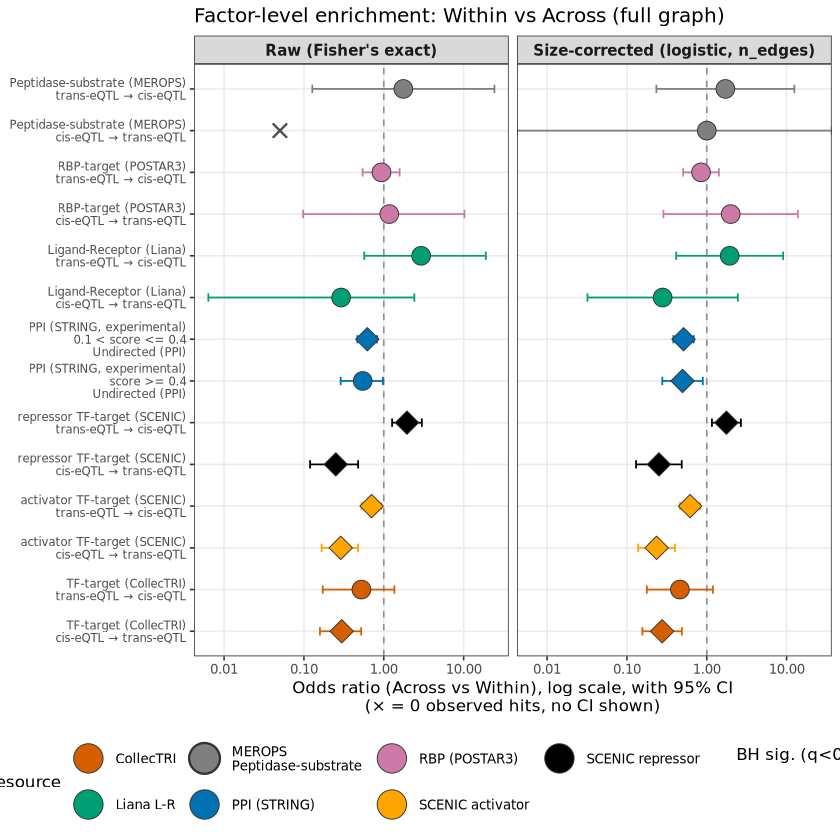

In [11]:
p_factor_two_level <- ggplot(factor_two_level, aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_key),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(data = factor_two_level[is_zero_hit == FALSE],
             aes(fill = resource_key, shape = sig_BH_05), color = "grey20", stroke = 0.4, size = 5) +
  geom_point(data = factor_two_level[is_zero_hit == TRUE],
             aes(fill = resource_key), shape = 4, size = 3, color = "grey30", stroke = 1) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)", na.translate = FALSE) +
  scale_fill_manual(values = resource_colors, name = "Resource", labels = resource_legend_labels) +
  scale_color_manual(values = resource_colors, guide = "none") +
  scale_x_log10() +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  facet_grid(cols = vars(level_group)) +
  labs(x = "Odds ratio (Across vs Within), log scale, with 95% CI\n(\u00d7 = 0 observed hits, no CI shown)",
       y = NULL, title = "Factor-level enrichment: Within vs Across (full graph)") +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_text(size = 7), strip.text = element_text(size = 9, face = "bold"),
        panel.grid.minor = element_blank(), legend.position = "bottom") +
  guides(fill = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1))

ggsave(paste0(outdir, "factor_level_fisher_vs_logistic_forest.png"), p_factor_two_level, width = 12,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(outdir, "factor_level_fisher_vs_logistic_forest.pdf"), p_factor_two_level, width = 12,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_factor_two_level


# Step 9: Composition stacked barplot

% of annotated (positive) factors per category that are Within vs Across,
same style/labels as `p_composition` in `Global_ER_replotting.ipynb`.

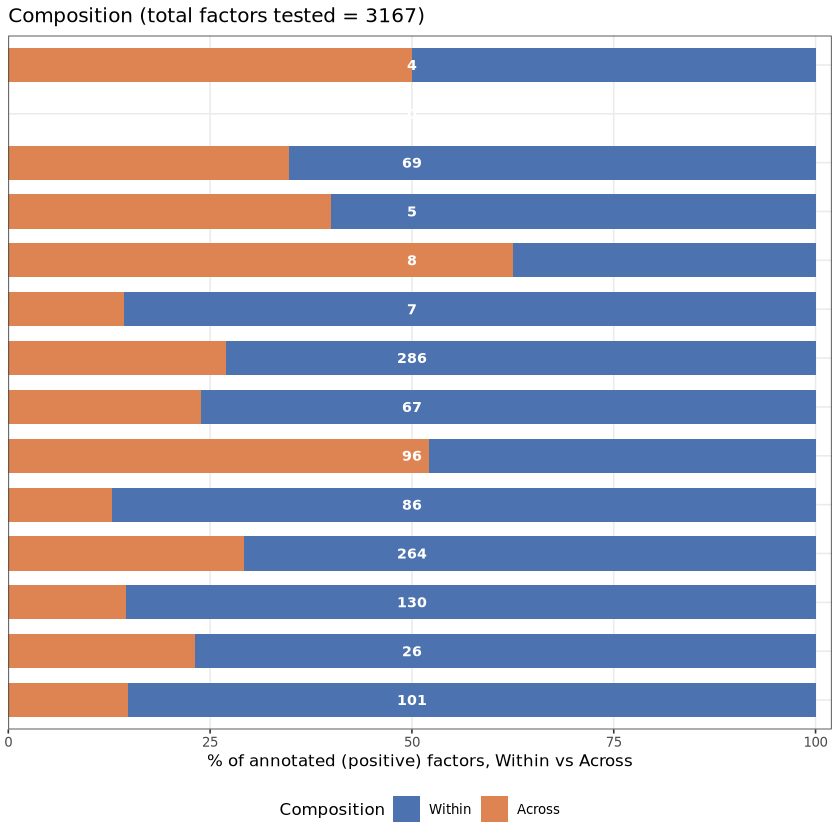

In [12]:
composition_factor <- fisher_results[, .(row_label = category_map[match(category, category_map$category)]$row_label,
                                           resource_key = category_map[match(category, category_map$category)]$resource_key,
                                           n_within_pos, n_across_pos)]
composition_factor[, n_total_pos := n_within_pos + n_across_pos]
composition_factor[, pct_within := 100 * n_within_pos / n_total_pos]
composition_factor[, pct_across := 100 * n_across_pos / n_total_pos]

composition_factor_long <- rbind(
  composition_factor[, .(row_label, n_total_pos, composition_type = "Within", pct = pct_within)],
  composition_factor[, .(row_label, n_total_pos, composition_type = "Across", pct = pct_across)]
)
composition_factor_long[, composition_type := factor(composition_type, levels = c("Within", "Across"))]

within_across_colors <- c("Within" = "#4C72B0", "Across" = "#DD8452")

p_composition_factor <- ggplot(composition_factor_long, aes(x = pct, y = row_label, fill = composition_type)) +
  geom_col(position = "stack", width = 0.7, na.rm = TRUE) +
  geom_text(data = unique(composition_factor_long[, .(row_label, n_total_pos)]),
            aes(x = 50, y = row_label, label = n_total_pos),
            inherit.aes = FALSE, hjust = 0.5, size = 3, color = "white", fontface = "bold") +
  scale_fill_manual(values = within_across_colors, name = "Composition") +
  scale_x_continuous(limits = c(0, 100), breaks = c(0, 25, 50, 75, 100), expand = expansion(mult = c(0, 0.02))) +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  labs(x = "% of annotated (positive) factors, Within vs Across", y = NULL,
       title = paste0("Composition (total factors tested = ", nrow(factors_for_testing), ")")) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
        strip.text = element_text(size = 8, face = "bold"), panel.grid.minor = element_blank(),
        legend.position = "bottom")

p_composition_factor


# Step 10: Combine odds-ratio panel + composition panel (75/25 split, legends at bottom)

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning messag

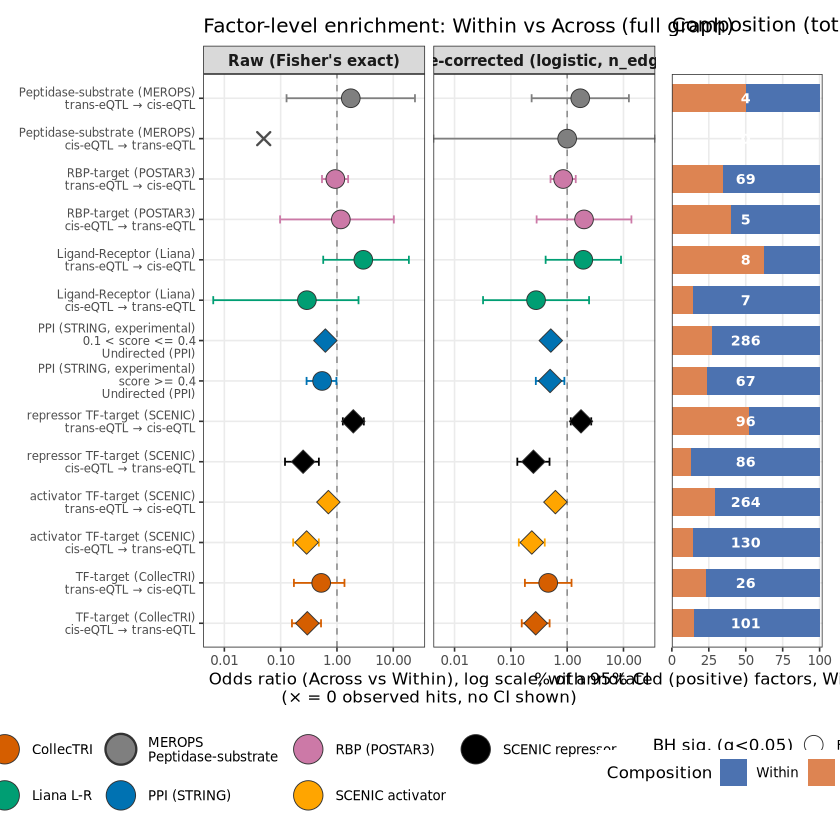

In [13]:
p_factor_side_by_side <- (p_factor_two_level | p_composition_factor) + plot_layout(widths = c(3, 1))

ggsave(paste0(outdir, "factor_level_combined_side_by_side.png"), p_factor_side_by_side, width = 16,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(outdir, "factor_level_combined_side_by_side.pdf"), p_factor_side_by_side, width = 16,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_factor_side_by_side


Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

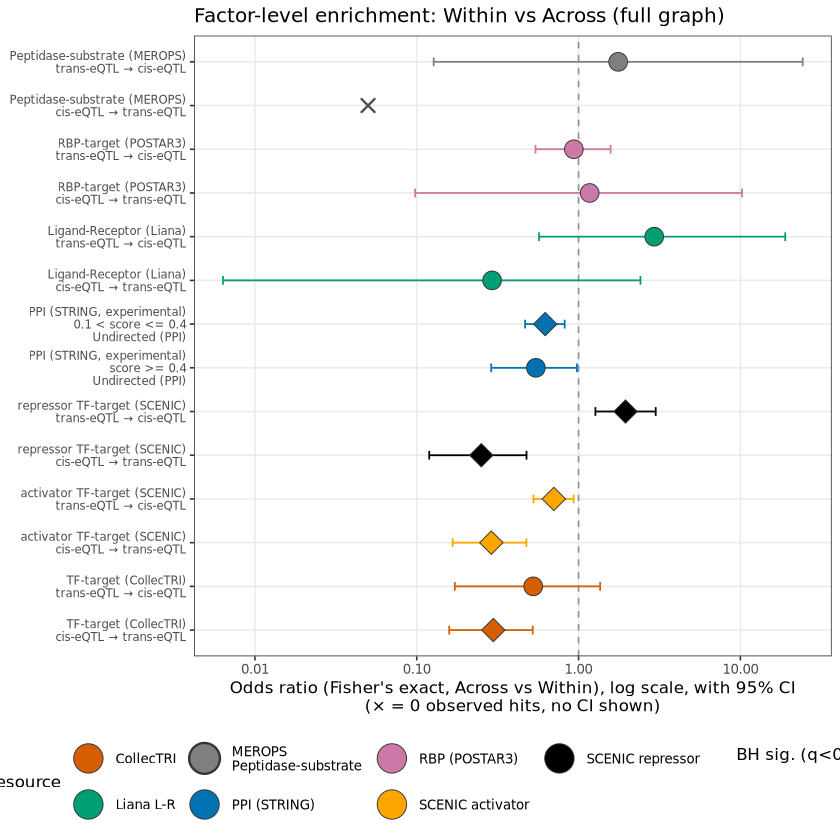

In [14]:
## =============================================================================
## Step 8 (updated): odds-ratio plot showing ONLY Fisher's exact results
## (drop the logistic facet - single panel now)
## =============================================================================
fisher_only <- factor_two_level[level_group == "Raw (Fisher's exact)"]

p_factor_two_level <- ggplot(fisher_only, aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_key),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(data = fisher_only[is_zero_hit == FALSE],
             aes(fill = resource_key, shape = sig_BH_05), color = "grey20", stroke = 0.4, size = 5) +
  geom_point(data = fisher_only[is_zero_hit == TRUE],
             aes(fill = resource_key), shape = 4, size = 3, color = "grey30", stroke = 1) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)", na.translate = FALSE) +
  scale_fill_manual(values = resource_colors, name = "Resource", labels = resource_legend_labels) +
  scale_color_manual(values = resource_colors, guide = "none") +
  scale_x_log10() +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  labs(x = "Odds ratio (Fisher's exact, Across vs Within), log scale, with 95% CI\n(\u00d7 = 0 observed hits, no CI shown)",
       y = NULL, title = "Factor-level enrichment: Within vs Across (full graph)") +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_text(size = 7), panel.grid.minor = element_blank(),
        legend.position = "bottom") +
  guides(fill = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1))

ggsave(paste0(outdir, "factor_level_fisher_only_forest.png"), p_factor_two_level, width = 9,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(outdir, "factor_level_fisher_only_forest.pdf"), p_factor_two_level, width = 9,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_factor_two_level

Total distinct programs (factors_for_testing): 585 


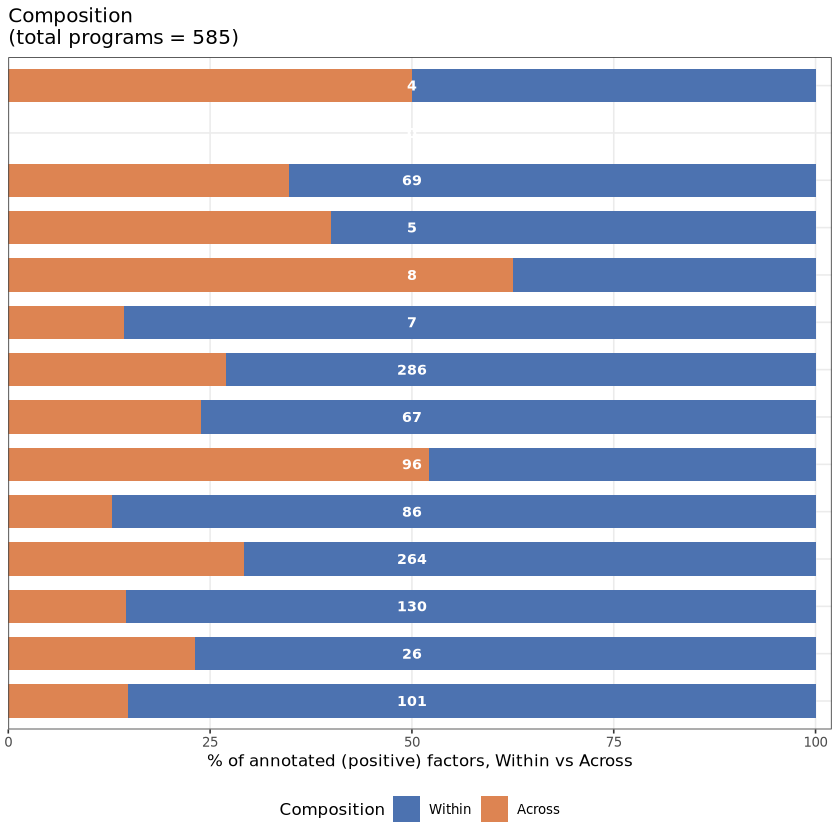

In [15]:
## =============================================================================
## Step 9 (updated): composition barplot + total number of PROGRAMS
## (distinct `program` count, same convention as the facet-strip totals in
## Global_ER_replotting.ipynb - there it was total factors/total pairs; here
## you asked specifically for total programs, i.e. uniqueN(program))
## =============================================================================
total_programs_n <- uniqueN(factors_for_testing$program)
cat("Total distinct programs (factors_for_testing):", total_programs_n, "\n")

composition_factor <- fisher_results[, .(row_label = category_map[match(category, category_map$category)]$row_label,
                                           resource_key = category_map[match(category, category_map$category)]$resource_key,
                                           n_within_pos, n_across_pos)]
composition_factor[, n_total_pos := n_within_pos + n_across_pos]
composition_factor[, pct_within := 100 * n_within_pos / n_total_pos]
composition_factor[, pct_across := 100 * n_across_pos / n_total_pos]

composition_factor_long <- rbind(
  composition_factor[, .(row_label, n_total_pos, composition_type = "Within", pct = pct_within)],
  composition_factor[, .(row_label, n_total_pos, composition_type = "Across", pct = pct_across)]
)
composition_factor_long[, composition_type := factor(composition_type, levels = c("Within", "Across"))]

within_across_colors <- c("Within" = "#4C72B0", "Across" = "#DD8452")

p_composition_factor <- ggplot(composition_factor_long, aes(x = pct, y = row_label, fill = composition_type)) +
  geom_col(position = "stack", width = 0.7, na.rm = TRUE) +
  geom_text(data = unique(composition_factor_long[, .(row_label, n_total_pos)]),
            aes(x = 50, y = row_label, label = n_total_pos),
            inherit.aes = FALSE, hjust = 0.5, size = 3, color = "white", fontface = "bold") +
  scale_fill_manual(values = within_across_colors, name = "Composition") +
  scale_x_continuous(limits = c(0, 100), breaks = c(0, 25, 50, 75, 100), expand = expansion(mult = c(0, 0.02))) +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  labs(x = "% of annotated (positive) factors, Within vs Across", y = NULL,
       title = paste0("Composition\n(total programs = ", total_programs_n, ")")) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
        strip.text = element_text(size = 8, face = "bold"), panel.grid.minor = element_blank(),
        legend.position = "bottom")

p_composition_factor

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

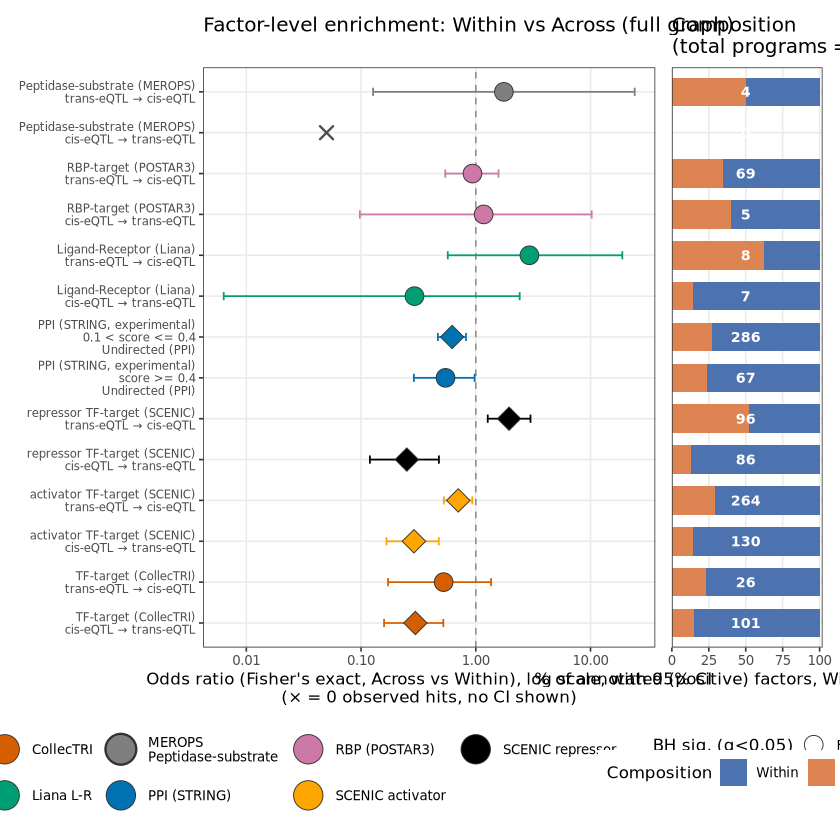

In [16]:
## =============================================================================
## Step 10 (updated): combine, same 75/25 split
## =============================================================================
p_factor_side_by_side <- (p_factor_two_level | p_composition_factor) + plot_layout(widths = c(3, 1))

ggsave(paste0(outdir, "factor_level_combined_side_by_side.png"), p_factor_side_by_side, width = 14,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(outdir, "factor_level_combined_side_by_side.pdf"), p_factor_side_by_side, width = 14,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_factor_side_by_side

In [17]:
cat("Distinct programs in whole_eqtl_annotated (the full, unrestricted pool):",
    uniqueN(whole_eqtl_annotated$program), "\n")
cat("Distinct programs in factor_topology_final (all factors, before Mixed exclusion):",
    uniqueN(factor_topology_final$program), "\n")
cat("Distinct programs in factors_for_testing (Mixed excluded):",
    uniqueN(factors_for_testing$program), "\n\n")

cat("Rows lost by restricting to factors_for_testing:",
    nrow(factor_topology_final) - nrow(factors_for_testing), "(should be 0, per Methods.md - no Mixed factors)\n\n")

cat("How many distinct (Source_module, Source_gene) combos share each program? Summary:\n")
print(summary(factor_topology_final[, .N, by = program]$N))

Distinct programs in whole_eqtl_annotated (the full, unrestricted pool): 585 
Distinct programs in factor_topology_final (all factors, before Mixed exclusion): 585 
Distinct programs in factors_for_testing (Mixed excluded): 585 

Rows lost by restricting to factors_for_testing: 0 (should be 0, per Methods.md - no Mixed factors)

How many distinct (Source_module, Source_gene) combos share each program? Summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   2.000   4.000   5.414   7.000  31.000 


# Rework to calculate the level of cis/trans network

Total cis/trans network units (Source_module, Source_gene, program combinations): 3167 


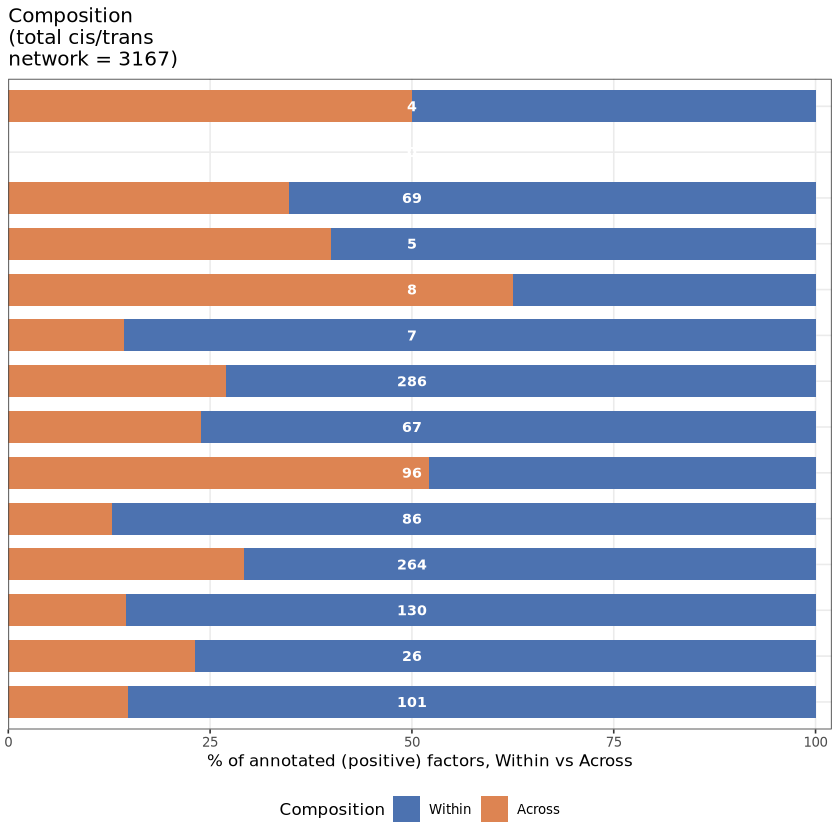

In [18]:
## =============================================================================
## Step 9 (corrected): total = count of the (Source_module, Source_gene,
## program) COMBINATION - i.e. the factor count itself (3167), labeled
## "cis/trans network" per your naming - not distinct program IDs (585).
## =============================================================================
total_cis_trans_network_n <- nrow(factors_for_testing)
cat("Total cis/trans network units (Source_module, Source_gene, program combinations):",
    total_cis_trans_network_n, "\n")

composition_factor <- fisher_results[, .(row_label = category_map[match(category, category_map$category)]$row_label,
                                           resource_key = category_map[match(category, category_map$category)]$resource_key,
                                           n_within_pos, n_across_pos)]
composition_factor[, n_total_pos := n_within_pos + n_across_pos]
composition_factor[, pct_within := 100 * n_within_pos / n_total_pos]
composition_factor[, pct_across := 100 * n_across_pos / n_total_pos]

composition_factor_long <- rbind(
  composition_factor[, .(row_label, n_total_pos, composition_type = "Within", pct = pct_within)],
  composition_factor[, .(row_label, n_total_pos, composition_type = "Across", pct = pct_across)]
)
composition_factor_long[, composition_type := factor(composition_type, levels = c("Within", "Across"))]

within_across_colors <- c("Within" = "#4C72B0", "Across" = "#DD8452")

p_composition_factor <- ggplot(composition_factor_long, aes(x = pct, y = row_label, fill = composition_type)) +
  geom_col(position = "stack", width = 0.7, na.rm = TRUE) +
  geom_text(data = unique(composition_factor_long[, .(row_label, n_total_pos)]),
            aes(x = 50, y = row_label, label = n_total_pos),
            inherit.aes = FALSE, hjust = 0.5, size = 3, color = "white", fontface = "bold") +
  scale_fill_manual(values = within_across_colors, name = "Composition") +
  scale_x_continuous(limits = c(0, 100), breaks = c(0, 25, 50, 75, 100), expand = expansion(mult = c(0, 0.02))) +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  labs(x = "% of annotated (positive) factors, Within vs Across", y = NULL,
       title = paste0("Composition\n(total cis/trans\nnetwork = ", total_cis_trans_network_n, ")")) +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank(),
        strip.text = element_text(size = 8, face = "bold"), panel.grid.minor = element_blank(),
        legend.position = "bottom")

p_composition_factor

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

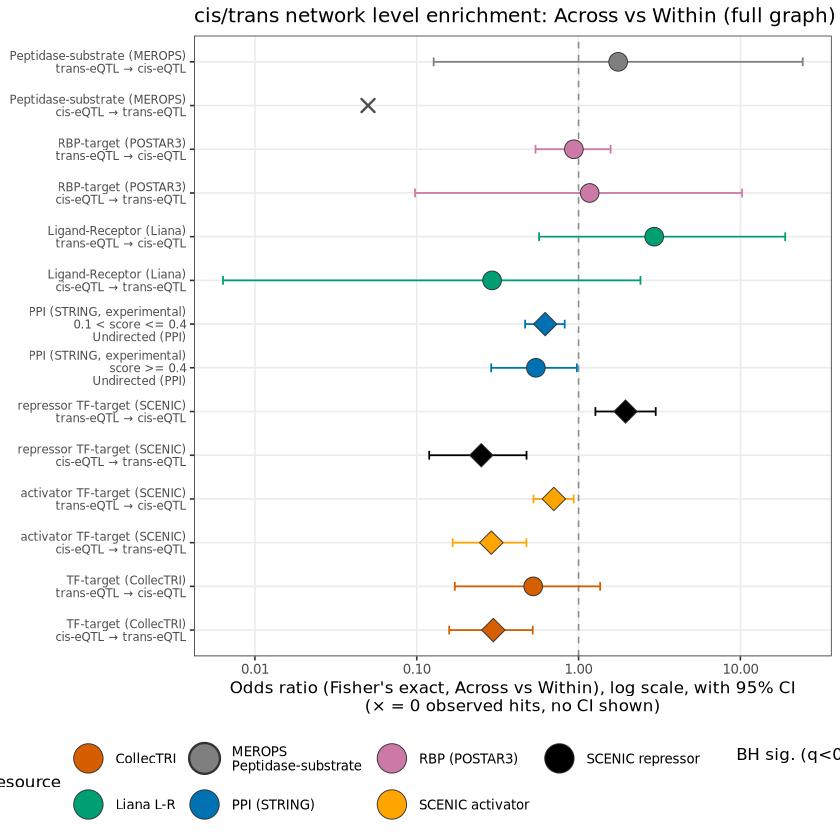

In [20]:
p_factor_two_level <- ggplot(fisher_only, aes(x = x_plot_final, y = row_label)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey40", alpha = 0.7) +
  geom_errorbar(aes(xmin = ci_low_plot, xmax = ci_high_plot, color = resource_key),
                orientation = "y", width = 0.2, linewidth = 0.5, na.rm = TRUE) +
  geom_point(data = fisher_only[is_zero_hit == FALSE],
             aes(fill = resource_key, shape = sig_BH_05), color = "grey20", stroke = 0.4, size = 5) +
  geom_point(data = fisher_only[is_zero_hit == TRUE],
             aes(fill = resource_key), shape = 4, size = 3, color = "grey30", stroke = 1) +
  scale_shape_manual(values = c("TRUE" = 23, "FALSE" = 21), name = "BH sig. (q<0.05)", na.translate = FALSE) +
  scale_fill_manual(values = resource_colors, name = "Resource", labels = resource_legend_labels) +
  scale_color_manual(values = resource_colors, guide = "none") +
  scale_x_log10() +
  scale_y_discrete(limits = axis_limits_bottom_to_top) +
  labs(x = "Odds ratio (Fisher's exact, Across vs Within), log scale, with 95% CI\n(\u00d7 = 0 observed hits, no CI shown)",
       y = NULL, title = "cis/trans network level enrichment: Across vs Within (full graph)") +
  theme_bw(base_size = 10) +
  theme(axis.text.y = element_text(size = 7), panel.grid.minor = element_blank(),
        legend.position = "bottom") +
  guides(fill = guide_legend(override.aes = list(size = 8, shape = 21, colour = "grey20"), order = 1))

ggsave(paste0(outdir, "cis_trans_network_fisher_forest.png"), p_factor_two_level, width = 9,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(outdir, "cis_trans_network_fisher_forest.pdf"), p_factor_two_level, width = 9,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_factor_two_level

## combined plot

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'cis-eQTL → trans-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'trans-eQTL → cis-eQTL' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call

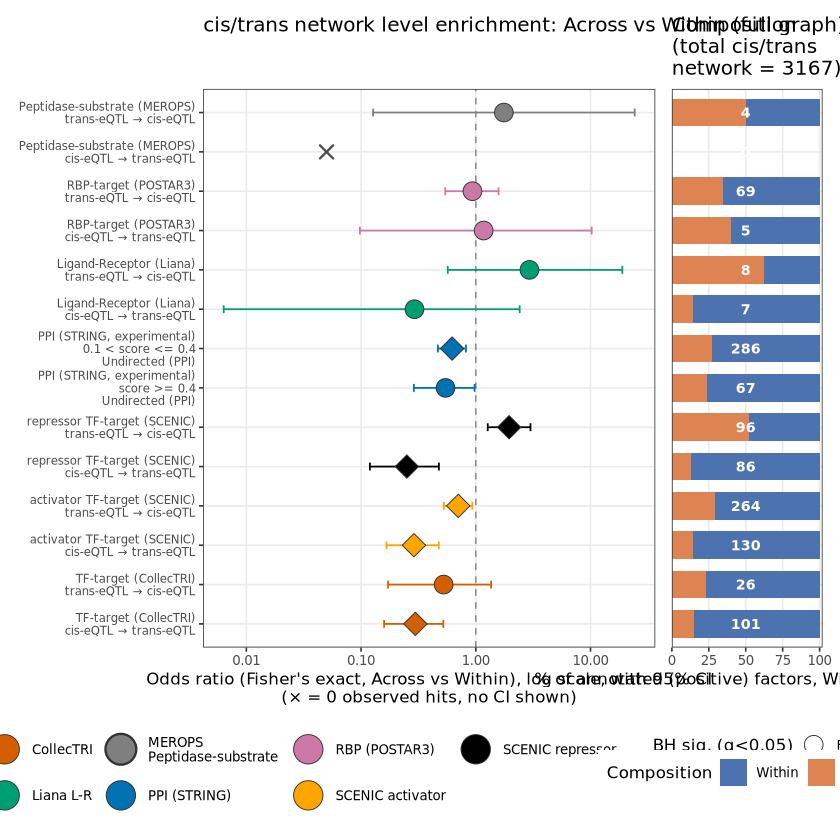

In [21]:
p_factor_side_by_side <- (p_factor_two_level | p_composition_factor) + plot_layout(widths = c(3, 1))

ggsave(paste0(outdir, "cis_trans_network_combined_side_by_side.png"), p_factor_side_by_side, width = 14,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), dpi = 200, bg = "white")
ggsave(paste0(outdir, "cis_trans_network_combined_side_by_side.pdf"), p_factor_side_by_side, width = 14,
       height = max(4, 0.35 * length(axis_limits_bottom_to_top) + 1.5), bg = "white")

p_factor_side_by_side

# Step 11: Save bundle for reuse elsewhere

Same pattern as the cis-eQTL and edge-level bundles: raw results, plot
metadata (colors/order), and the built ggplot objects, in one RDS.

In [22]:
## =============================================================================
## Save cis/trans network level results + plotting metadata, for combining
## with the edge level and cis-eQTL (gene-pair) level in Global_ER_replotting.ipynb
## =============================================================================
cis_trans_network_plot_metadata <- list(
  resource_colors          = resource_colors,
  resource_legend_labels   = resource_legend_labels,
  row_order_top_to_bottom  = row_order_top_to_bottom,
  axis_limits_bottom_to_top = axis_limits_bottom_to_top,
  category_map              = category_map,

  level_name         = "cis/trans network",
  grain_definition   = "(Source_module, Source_gene, program) combination",
  total_n            = total_cis_trans_network_n,
  subset_applied     = "full graph only (Within-only vs Across-only, Mixed excluded)",
  x_variable         = "odds_ratio (Fisher's exact)",
  odds_ratio_convention = "OR = odds(category present | Across-only) / odds(category present | Within-only)",
  zero_hit_handling  = "odds_ratio == 0 or non-finite -> plotted as a cross at x_axis_floor (0.05), no CI shown",

  generated_on = Sys.time(),
  r_session    = capture.output(sessionInfo())
)

cis_trans_network_bundle <- list(
  fisher_results          = fisher_results,          # raw per-category Fisher results
  fisher_only             = fisher_only,              # plotted table: fisher_results + row_label/resource_key/is_zero_hit/x_plot_final etc.
  composition_factor_long = composition_factor_long,  # plotted composition table (long format, pct + n_total_pos)
  plot_metadata           = cis_trans_network_plot_metadata
)

saveRDS(cis_trans_network_bundle, file = paste0(outdir, "cis_trans_network_results_bundle.rds"))

## Human-readable companions
fwrite(fisher_results, paste0(outdir, "cis_trans_network_fisher_results.tsv"), sep = "\t")
fwrite(fisher_only, paste0(outdir, "cis_trans_network_fisher_only_plotted.tsv"), sep = "\t")
fwrite(composition_factor_long, paste0(outdir, "cis_trans_network_composition_plotted.tsv"), sep = "\t")

cat("Saved bundle to:", paste0(outdir, "cis_trans_network_results_bundle.rds"), "\n")
cat("Saved companions: cis_trans_network_fisher_results.tsv, cis_trans_network_fisher_only_plotted.tsv, cis_trans_network_composition_plotted.tsv\n")

Saved bundle to: /nfs/team151/mt19/overhaul_classification_factors_with_programs/Factor_ER/cis_trans_network_results_bundle.rds 
Saved companions: cis_trans_network_fisher_results.tsv, cis_trans_network_fisher_only_plotted.tsv, cis_trans_network_composition_plotted.tsv
